In [5]:
from evaluation.shap_analysis import run_shap_analysis
import joblib
import pandas as pd
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

# Load processed features
X_train_final = joblib.load("../data/processed/X_train_final.pkl")

# One-hot encode and convert to float
X_train_clean = pd.get_dummies(X_train_final, drop_first=True).astype(float)

# Run SHAP and display figure in notebook
run_shap_analysis(X_train_clean)


100%|===================| 3769/3780 [00:45<00:00]        

SHAP analysis completed


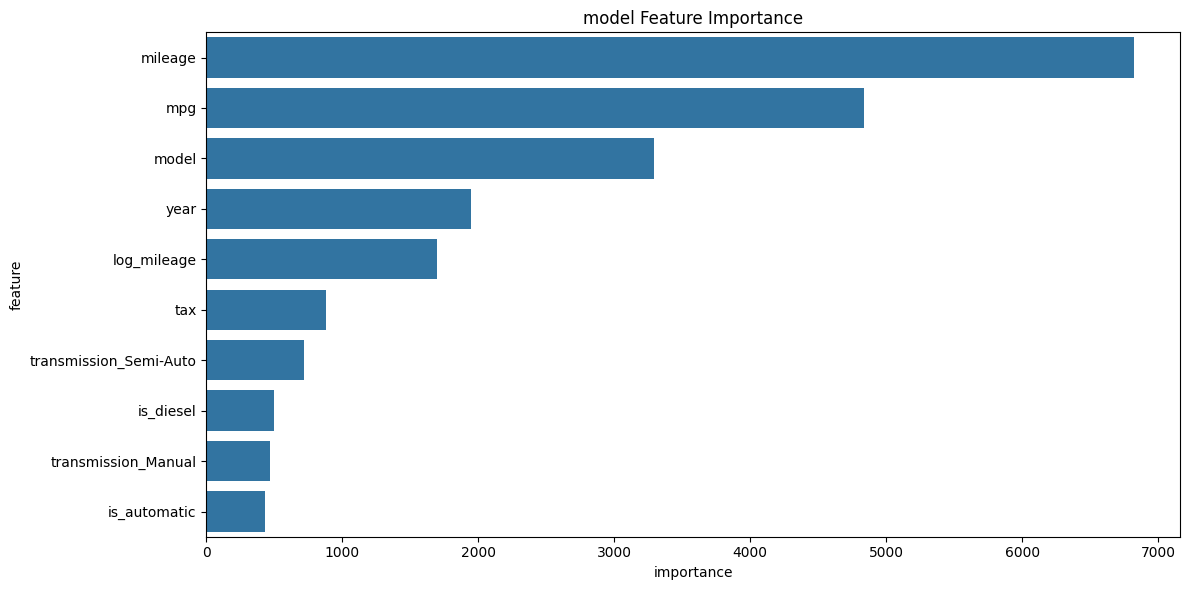

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

# Load model
MODELS_DIR = Path("../src/models")
model = joblib.load(MODELS_DIR / "model_tuned_optuna.pkl")
booster = model.get_booster()

# Get feature importances (weight, gain, cover)
importance_dict = booster.get_score(importance_type='weight')  # or 'gain' for more meaningful importance

# Convert to DataFrame
feat_imp_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=feat_imp_df)
plt.title("model Feature Importance")
plt.tight_layout()
plt.show()


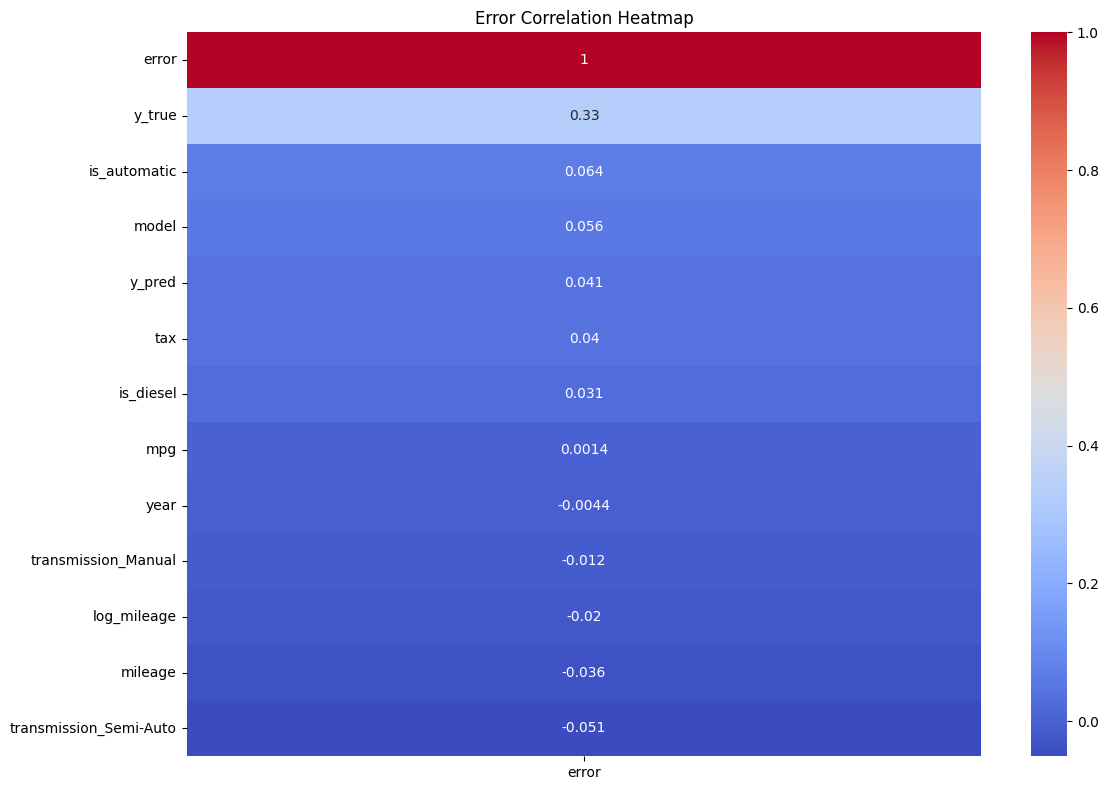

High-error rows (top 10%):
      year  mileage  log_mileage   mpg  model  tax  transmission_Semi-Auto  \
5577  2020      700     6.552508  34.0      7  145                    True   
2418  2019     5234     8.563122  68.9      6  145                   False   
6120  2019      151     5.023881  60.1      3  145                   False   
4400  2019     9882     9.198571  34.0      7  145                    True   
3458  2019     3069     8.029433  34.5      0  150                    True   
...    ...      ...          ...   ...    ...  ...                     ...   
3888  2019     4394     8.388223  53.3      2  150                    True   
3881  2020     1550     7.346655  53.3      6  145                    True   
5918  2019     1000     6.908755  60.1      3  145                   False   
9926  2013    30000    10.308986  50.4      8  165                   False   
1677  2019    13216     9.489259  60.1      2  145                    True   

      transmission_Manual  is_automa

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


y_train = joblib.load("../data/processed/y_train.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

X_test_old = X_test_final[['year', 'mileage', 'log_mileage', 'mpg', 'model', 'tax', 'transmission_Semi-Auto', 'transmission_Manual', 'is_automatic', 'is_diesel']]
# 1️⃣ Predict
y_pred = model.predict(X_test_old)

# 2️⃣ Compute errors (regression example)
errors = y_test - y_pred

# 3️⃣ Prepare DataFrame
X_test_df = X_test_final.copy()  # Ensure X_test is a DataFrame
X_test_df['error'] = errors
X_test_df['y_true'] = y_test
X_test_df['y_pred'] = y_pred

# 4️⃣ Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X_test_df.corr()[['error']].sort_values(by='error', ascending=False), annot=True, cmap='coolwarm')
plt.title("Error Correlation Heatmap")
plt.tight_layout()
plt.show()

# 5️⃣ Optional: high-error rows
threshold = errors.abs().quantile(0.9)  # top 10% errors
high_error_rows = X_test_df[errors.abs() > threshold]
print("High-error rows (top 10%):")
print(high_error_rows)
